# WO3: Environmental discrimination of cultural traits — variance-based, with culture-history control

Supersedes `wo2_causal-distance.ipynb`. Reuses that notebook's data assembly, trait merges, and
n-floor conventions; its readings and conclusions are a different question (range-based spread)
and are not consulted here. Fresh measure (ω²/η²) on the same six-trait, five-dimension
substrate.

## Data assembly

Same substrate as WO1/WO2: `wo8c_substrate.parquet` (1,133 basin-joined D-PLACE EA societies)
plus the four traits merged in WO2 (EA030/EA031/EA033/EA066) and continent.

In [1]:
# Cell 1
%matplotlib inline
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.shared import db_utils
from scripts.shared.db_utils import db_connect
from scripts.cdop.distance_core import VARIABLES

ROOT = Path(db_utils.__file__).parent.parent.parent
OUT = ROOT / 'output' / 'edop' / 'docsv4'
OUT.mkdir(parents=True, exist_ok=True)
SUBSTRATE_PATH = ROOT / 'output' / 'cdop' / 'wo8c_substrate.parquet'

conn = db_connect()
substrate = pd.read_parquet(SUBSTRATE_PATH)
print(f"connected; substrate: {len(substrate)} basin-joined EA societies, {len(substrate.columns)} columns")


connected; substrate: 1133 basin-joined EA societies, 35 columns


In [2]:
# Cell 2
NEW_TRAITS = {
    'ea030_settlement':      'EA030',
    'ea031_community_size':  'EA031',
    'ea033_juris_hierarchy': 'EA033',
    'ea066_class_strat':     'EA066',
}
for col, var in NEW_TRAITS.items():
    codes = pd.read_sql(f"""
        SELECT s.id AS soc_id, c.name AS {col}
        FROM dplace.societies s
        JOIN dplace.data d ON d.soc_id = s.id AND d.var_id = '{var}'
        JOIN dplace.codes c ON c.id = d.code_id AND c.name NOT IN ('Missing data', '')
        WHERE s.contribution_id = 'dplace-dataset-ea'
    """, conn)
    substrate = substrate.merge(codes, on='soc_id', how='left')

counts = ", ".join(f"{col}={substrate[col].notna().sum()}" for col in NEW_TRAITS)
print(f"Merged onto the {len(substrate)}-row basin-joined substrate. Coded counts "
      f"(basin-joined only, before the n>=20 category floor): {counts}")


Merged onto the 1133-row basin-joined substrate. Coded counts (basin-joined only, before the n>=20 category floor): ea030_settlement=1044, ea031_community_size=539, ea033_juris_hierarchy=1012, ea066_class_strat=970


In [3]:
# Cell 3
continent_df = pd.read_sql("""
    SELECT s.id AS soc_id, a.continent
    FROM dplace.societies s
    LEFT JOIN gaz.admin0 a
        ON ST_Contains(a.geom, ST_SetSRID(ST_MakePoint(s.longitude, s.latitude), 4326))
    WHERE s.contribution_id = 'dplace-dataset-ea'
""", conn)
substrate = substrate.merge(continent_df, on='soc_id', how='left')
print(f"Continent merged; {substrate['continent'].notna().sum()} of {len(substrate)} "
      f"basin-joined societies matched to a continent polygon.")


Continent merged; 1127 of 1133 basin-joined societies matched to a continent polygon.


## Declared tier table and prediction

| Tier | Trait | EA code |
|---|---|---|
| 1 — Direct material constraint | Dominant subsistence | EA042 |
| 2 — Settlement form | Settlement pattern | EA030 |
| 2 — Settlement form | Mean community size | EA031 |
| 3 — Social organization | Jurisdictional hierarchy | EA033 |
| 3 — Social organization | Class differentiation (primary) | EA066 |
| 4 — Cosmology | High gods | EA034 |

**Prediction:** environmental discrimination declines as traits move away from direct material
constraint — most stringently on the within-continent series (the culture-history control). No
trait is added, dropped, or moved between tiers after its result is computed; a non-monotonic
result is a finding, not a failure.

**Tier 1 caveat, stated up front:** EA042 (dominant subsistence) is close to an environmental
measurement in the first place — fishing requires water, pastoralism requires rangeland. Tier 1
scoring high is therefore partly definitional, and is the *weakest*, not the strongest, evidence
that environment shapes culture.

**EA031 caveat:** carries a thin coded base (roughly half the societies of the other traits) —
flagged in every table it appears in, not treated as equivalent to the other five.

## Measure: ω² / η² one-way variance decomposition

Per trait × dimension, a one-way decomposition of the environmental percentile (`{dim}__pct`) on
trait category:

- **η² (eta-squared)** = SS_between / SS_total — unadjusted proportion of variance.
- **ω² (omega-squared)** = (SS_between − df_between·MS_within) / (SS_total + MS_within) — adjusts
  for degrees of freedom, so it is comparable across traits with different category counts.
  Reported as the headline; η² alongside so the size of the adjustment is visible.

Descriptive effect sizes only — no p-values, no F-test significance language, no PERMANOVA.

**Within-continent pooled version:** the same decomposition computed inside each continent
stratum and pooled — sum of within-continent SS_between over sum of within-continent SS_total,
with the same df adjustment applied to the pooled sums for ω². A trait whose discrimination
survives this is discriminating for reasons other than continental clustering; a trait whose
discrimination collapses was tracking geography.

**Continent comparator:** ω² of the same dimension on continent itself, computed on each trait's
own coded row set, as a direct comparison point.

## Computation machinery

n-floor = 20 per trait category (WO2 convention); within-continent stratum floor = 2+ categories
with n ≥ 10 each, fixed before computing.

In [4]:
# Cell 4
VAR_KEYS = list(VARIABLES.keys())  # aridity, temperature, seasonality, ruggedness, landform
N_FLOOR = 20

substrate_pct = substrate.copy()
if 'ari_log' not in substrate_pct.columns and 'ari_ix_sav' in substrate_pct.columns:
    substrate_pct['ari_log'] = np.log1p(substrate_pct['ari_ix_sav'])  # matches distance_core's own derivation
for k in VAR_KEYS:
    col = VARIABLES[k]['column']
    substrate_pct[f'{k}__pct'] = substrate_pct[col].rank(pct=True) * 100

def kept_categories(series, min_n=N_FLOOR):
    """Category value_counts split at the n-floor -- kept (>=min_n) and dropped, never silently
    discarded."""
    counts = series.value_counts()
    keep = counts[counts >= min_n].index.tolist()
    dropped = counts[counts < min_n]
    return keep, dropped

print(f"percentile columns built for {len(VAR_KEYS)} dimensions; n-floor={N_FLOOR}.")


percentile columns built for 5 dimensions; n-floor=20.


In [5]:
# Cell 5
def anova_effect_sizes(df, value_col, group_col, categories=None):
    """One-way decomposition of `value_col` by `group_col`. If `categories` is given, rows
    outside it are excluded before computing (the n-floor is applied by the caller, not here).
    omega2 is left unclipped at 0 -- a negative value is itself informative (effect
    indistinguishable from zero-or-below under this estimator), not an error to suppress."""
    sub = df[[value_col, group_col]].dropna()
    if categories is not None:
        sub = sub[sub[group_col].isin(categories)]
    k = sub[group_col].nunique()
    n = len(sub)
    if k < 2 or n - k < 1:
        return dict(eta2=np.nan, omega2=np.nan, k=k, n=n, df_between=np.nan, df_within=np.nan)
    grand_mean = sub[value_col].mean()
    groups = sub.groupby(group_col)[value_col]
    ss_between = float(sum(len(g) * (g.mean() - grand_mean) ** 2 for _, g in groups))
    ss_total = float(((sub[value_col] - grand_mean) ** 2).sum())
    ss_within = ss_total - ss_between
    df_between = k - 1
    df_within = n - k
    ms_within = ss_within / df_within
    eta2 = ss_between / ss_total if ss_total > 0 else np.nan
    omega2 = (ss_between - df_between * ms_within) / (ss_total + ms_within) if (ss_total + ms_within) > 0 else np.nan
    return dict(eta2=eta2, omega2=omega2, ss_between=ss_between, ss_within=ss_within,
                ss_total=ss_total, k=k, n=n, df_between=df_between, df_within=df_within)

print("anova_effect_sizes() defined.")


anova_effect_sizes() defined.


In [6]:
# Cell 6
STRATUM_CAT_FLOOR = 10
STRATUM_MIN_CATS = 2

def continent_strata(df, trait_col, kept_cats, continent_col='continent',
                      cat_floor=STRATUM_CAT_FLOOR, min_cats=STRATUM_MIN_CATS):
    """Which continents qualify for the within-continent pool for this trait, and which
    trait categories survive the floor inside each qualifying continent. Depends only on
    (trait_col, continent) counts -- computed once per trait, reused across all five
    dimensions, since the floor test doesn't touch the environmental variable at all."""
    sub = df[[trait_col, continent_col]].dropna()
    sub = sub[sub[trait_col].isin(kept_cats)]
    included, excluded = {}, {}
    for cont, g in sub.groupby(continent_col):
        counts = g[trait_col].value_counts()
        strat_cats = counts[counts >= cat_floor].index.tolist()
        if len(strat_cats) < min_cats:
            excluded[cont] = {'n_categories_ge_floor': len(strat_cats), 'n_rows': int(len(g))}
        else:
            included[cont] = strat_cats
    return included, excluded

def pooled_omega_eta(df, value_col, trait_col, included_strata, continent_col='continent'):
    """Pooled eta2/omega2 across the qualifying continent strata -- sum of within-continent
    SS_between over sum of within-continent SS_total, df-adjusted for omega2 (WO3 Sec 3)."""
    ss_b_sum = ss_w_sum = 0.0
    df_b_sum = df_w_sum = 0
    for cont, cats in included_strata.items():
        gg = df[(df[continent_col] == cont) & (df[trait_col].isin(cats))][[value_col, trait_col]].dropna()
        grand_mean = gg[value_col].mean()
        groups = gg.groupby(trait_col)[value_col]
        ss_b = float(sum(len(gr) * (gr.mean() - grand_mean) ** 2 for _, gr in groups))
        ss_t = float(((gg[value_col] - grand_mean) ** 2).sum())
        k = groups.ngroups
        n = len(gg)
        ss_b_sum += ss_b
        ss_w_sum += (ss_t - ss_b)
        df_b_sum += (k - 1)
        df_w_sum += (n - k)
    ss_t_sum = ss_b_sum + ss_w_sum
    if df_w_sum <= 0 or ss_t_sum <= 0:
        return np.nan, np.nan
    ms_w = ss_w_sum / df_w_sum
    eta2 = ss_b_sum / ss_t_sum
    omega2 = (ss_b_sum - df_b_sum * ms_w) / (ss_t_sum + ms_w)
    return eta2, omega2

print("continent_strata() / pooled_omega_eta() defined.")


continent_strata() / pooled_omega_eta() defined.


## Table 1 — Marginal discrimination

In [7]:
# Cell 7
TIER_TRAITS = [
    (1, 'ea042_subsistence',     'EA042 Dominant subsistence'),
    (2, 'ea030_settlement',      'EA030 Settlement pattern'),
    (2, 'ea031_community_size',  'EA031 Mean community size'),
    (3, 'ea033_juris_hierarchy', 'EA033 Jurisdictional hierarchy'),
    (3, 'ea066_class_strat',     'EA066 Class differentiation'),
    (4, 'ea034_religion',        'EA034 High gods'),
]
THIN_BASE_TRAIT = 'ea031_community_size'

KEPT, DROPPED = {}, {}
for _, col, _ in TIER_TRAITS:
    KEPT[col], DROPPED[col] = kept_categories(substrate_pct[col])

table1_rows = []
for tier, col, label in TIER_TRAITS:
    keep = KEPT[col]
    omega2s, eta2s = {}, {}
    row = {'tier': tier, 'trait': label,
           'n_categories_kept': len(keep), 'n_categories_dropped': len(DROPPED[col]),
           'thin_base': (col == THIN_BASE_TRAIT)}
    for k in VAR_KEYS:
        res = anova_effect_sizes(substrate_pct, f'{k}__pct', col, categories=keep)
        omega2s[k], eta2s[k] = res['omega2'], res['eta2']
        row[f'{k}__omega2'] = res['omega2']
        row[f'{k}__eta2'] = res['eta2']
    max_dim_omega = max(VAR_KEYS, key=lambda k: omega2s[k] if pd.notna(omega2s[k]) else -np.inf)
    max_dim_eta = max(VAR_KEYS, key=lambda k: eta2s[k] if pd.notna(eta2s[k]) else -np.inf)
    row['max_dim'] = max_dim_omega
    row['max_omega2'] = omega2s[max_dim_omega]
    row['mean_omega2'] = float(np.nanmean(list(omega2s.values())))
    row['max_dim_eta2'] = max_dim_eta
    row['max_dim_agrees'] = (max_dim_omega == max_dim_eta)
    table1_rows.append(row)

table1_df = pd.DataFrame(table1_rows)
display_cols = ['tier', 'trait', 'thin_base', 'n_categories_kept', 'n_categories_dropped',
                 'max_dim', 'max_omega2', 'mean_omega2', 'max_dim_eta2', 'max_dim_agrees']
print(table1_df[display_cols].round(3).to_string(index=False))


 tier                          trait  thin_base  n_categories_kept  n_categories_dropped     max_dim  max_omega2  mean_omega2 max_dim_eta2  max_dim_agrees
    1     EA042 Dominant subsistence      False                  7                     0 seasonality       0.332        0.181  seasonality            True
    2       EA030 Settlement pattern      False                  7                     1 seasonality       0.269        0.109  seasonality            True
    2      EA031 Mean community size       True                  7                     1 seasonality       0.067        0.024  seasonality            True
    3 EA033 Jurisdictional hierarchy      False                  5                     0 temperature       0.052        0.027  temperature            True
    3    EA066 Class differentiation      False                  5                     0 temperature       0.031        0.020  temperature            True
    4                EA034 High gods      False                  4    

**Reading (marginal only — Table 1, before continent control):** Not monotonic on the headline
measure (max ω²): Tier 1 EA042 (0.332) > Tier 2 EA030 (0.269) > Tier 2 EA031 (0.067) > Tier 3
EA033 (0.052) > Tier 3 EA066 (0.031), but Tier 4 EA034 (0.110) exceeds both Tier 3 traits —
cosmology, the tier furthest from material constraint, is not the least environmentally
discriminated trait on this marginal measure. Max-ω² and max-η² dimensions agree for every trait
(`max_dim_agrees` all True), so there is no headline/secondary disagreement to adjudicate here.

The dominant dimension itself has shifted from WO2: seasonality is the max-ω² dimension for four
of six traits (EA042, EA030, EA031, EA034), temperature for the other two (EA033, EA066) —
aridity, which dominated 5 of 6 traits in WO2's range-based spread, is the max dimension for none
here. This is a measure-change effect worth flagging, not yet a substantive finding: ω² weights
all kept categories' between/within spread, where WO2's range statistic was driven by the single
most extreme pair of categories, so the two measures can reasonably disagree about which dimension
dominates on the same data.

This is the marginal series only — before continent is held fixed. Per WO3's own discipline, none
of this can yet be described as surviving or not surviving culture-history control; that reading
only applies once Table 2's within-continent pooled ω² is in hand. EA030 and EA031 each dropped
one below-floor category (7 kept, 1 dropped); EA031 carries its usual thin-base flag
(`thin_base=True`) on top of that.

## Table 2 — Within-continent pooled discrimination

In [8]:
# Cell 8
table2_rows = []
STRATA = {}
for tier, col, label in TIER_TRAITS:
    included, excluded = continent_strata(substrate_pct, col, KEPT[col])
    STRATA[col] = (included, excluded)
    row = {'tier': tier, 'trait': label, 'thin_base': (col == THIN_BASE_TRAIT),
           'n_continents_included': len(included), 'n_continents_excluded': len(excluded),
           'continents_included': sorted(included.keys()),
           'continents_excluded': sorted(excluded.keys())}
    omega2s = {}
    for k in VAR_KEYS:
        eta2, omega2 = pooled_omega_eta(substrate_pct, f'{k}__pct', col, included)
        omega2s[k] = omega2
        row[f'{k}__omega2'] = omega2
        row[f'{k}__eta2'] = eta2
    row['headline_dim_omega2'] = omega2s[table1_df.loc[table1_df['trait'] == label, 'max_dim'].iloc[0]]
    table2_rows.append(row)

table2_df = pd.DataFrame(table2_rows)
display_cols = ['tier', 'trait', 'thin_base', 'n_continents_included', 'n_continents_excluded',
                 'headline_dim_omega2'] + [f'{k}__omega2' for k in VAR_KEYS]
print(table2_df[display_cols].round(3).to_string(index=False))
print()
for tier, col, label in TIER_TRAITS:
    included, excluded = STRATA[col]
    excl_note = {c: excluded[c]['n_categories_ge_floor'] for c in excluded}
    print(f"{label}: included={sorted(included.keys())}  excluded(n_cats>=floor)={excl_note}")


 tier                          trait  thin_base  n_continents_included  n_continents_excluded  headline_dim_omega2  aridity__omega2  temperature__omega2  seasonality__omega2  ruggedness__omega2  landform__omega2
    1     EA042 Dominant subsistence      False                      4                      2                0.215            0.319                0.126                0.215               0.018             0.011
    2       EA030 Settlement pattern      False                      4                      2                0.166            0.160                0.053                0.166               0.013             0.010
    2      EA031 Mean community size       True                      5                      1                0.073            0.054                0.025                0.073               0.051            -0.011
    3 EA033 Jurisdictional hierarchy      False                      4                      2                0.036            0.060                0.036

**Reading (within-continent, Table 2):** Attenuation on each trait's fixed headline dim
(within-continent ω² / marginal ω²): EA042 0.65, EA030 0.62, EA031 1.09 (thin-base, discount),
EA033 0.69, EA066 0.90 — and **EA034 2.43, more than doubling rather than attenuating**. The
declared prediction breaks hardest exactly where it mattered most: EA034 (Tier 4, theoretically
furthest from material constraint) has the *largest* within-continent value in the table (0.267),
exceeding EA042's own (0.215). On the culture-history-controlled series, the ordering is EA034
(T4) > EA042 (T1) > EA030 (T2) > EA031 (T2) > EA033 (T3) > EA066 (T3) — non-monotonic on the
pre-committed headline measure, and not in the tier-predicted direction.

Two secondary observations, both descriptive and not overriding the fixed-headline rule: aridity
stays large within-continent even where it isn't a trait's declared headline dim (EA042's aridity
0.319 exceeds its own headline 0.215; EA066's aridity 0.121 dwarfs its headline 0.028) — the
opposite of the confounding signature WO3 §7 describes, since aridity isn't collapsing. And Tier 3
(EA033/EA066) pools a different continent set than Tiers 1/2/4 — {Africa, Asia, Europe, North
America} vs. {Africa, Asia, North America, South America} — so Tier 3's numbers aren't just
noisier, they're computed on non-overlapping continents, weakening any tier-to-tier comparison
that involves EA033/EA066 specifically.

Landform stays near-zero or slightly negative for every trait, consistent with Table 1
(unclipped, per the decision log).

## Table 3 — Continent's own discrimination (comparator)

In [9]:
# Cell 9
def continent_comparator(df, value_col, trait_col, continent_col='continent', min_n=N_FLOOR):
    """omega2/eta2 of `value_col` on continent, restricted to rows where `trait_col` is
    coded (WO3 Sec 3's own row-set wording) -- not restricted to the trait's kept categories,
    which is a different row set (Table 1/2). Continent categories within that row set are
    floored at the same n-floor as trait categories, for the same reason: an unfloored
    six-way ANOVA on a coded-but-thin row set is unstable the same way an unfloored trait
    category would be."""
    sub = df[df[trait_col].notna()]
    keep, dropped = kept_categories(sub[continent_col], min_n)
    res = anova_effect_sizes(sub, value_col, continent_col, categories=keep)
    res['continents_kept'] = keep
    res['continents_dropped'] = list(dropped.index)
    return res

table3_rows = []
for tier, col, label in TIER_TRAITS:
    headline_dim = table1_df.loc[table1_df['trait'] == label, 'max_dim'].iloc[0]
    row = {'tier': tier, 'trait': label, 'thin_base': (col == THIN_BASE_TRAIT), 'headline_dim': headline_dim}
    for k in VAR_KEYS:
        res = continent_comparator(substrate_pct, f'{k}__pct', col)
        row[f'{k}__omega2'] = res['omega2']
        row[f'{k}__eta2'] = res['eta2']
    row['headline_dim_omega2'] = row[f'{headline_dim}__omega2']
    table3_rows.append(row)

table3_df = pd.DataFrame(table3_rows)
display_cols = ['tier', 'trait', 'thin_base', 'headline_dim', 'headline_dim_omega2'] + [f'{k}__omega2' for k in VAR_KEYS]
print(table3_df[display_cols].round(3).to_string(index=False))


 tier                          trait  thin_base headline_dim  headline_dim_omega2  aridity__omega2  temperature__omega2  seasonality__omega2  ruggedness__omega2  landform__omega2
    1     EA042 Dominant subsistence      False  seasonality                0.504            0.130                0.504                0.504               0.110             0.001
    2       EA030 Settlement pattern      False  seasonality                0.533            0.134                0.526                0.533               0.108             0.004
    2      EA031 Mean community size       True  seasonality                0.538            0.133                0.512                0.538               0.120            -0.005
    3 EA033 Jurisdictional hierarchy      False  temperature                0.531            0.138                0.531                0.546               0.109             0.003
    3    EA066 Class differentiation      False  temperature                0.528            0.135       

**Reading (continent comparator, Table 3):** Continent's own ω² on the headline dims
(temperature/seasonality) sits at ~0.48–0.54 for all six traits — far above any trait's own
marginal ω² (Table 1 max was 0.332). Continent alone explains roughly half the variance in
temperature and seasonality; that's a large confound sitting behind every trait here, since all
six landed on seasonality or temperature as their headline dimension (none picked aridity).

It's dimension-specific, not uniform: aridity's continent ω² is only ~0.13–0.15 — continent is a
comparatively weak determinant of aridity. This strengthens the Table 2 reading rather than
undercutting it: EA034's within-continent seasonality ω² (0.267) isn't surviving a token
confound, it's surviving removal of a genuinely large ~0.5 geographic baseline, and still comes
out larger than its own marginal value.

Landform's continent ω² is ~0 everywhere, matching landform's weak showing throughout all three
tables; ruggedness sits at a fairly flat ~0.10–0.12 across traits.

## Table 4 — Attenuation

In [10]:
# Cell 10
attenuation_rows = []
for tier, col, label in TIER_TRAITS:
    headline_dim = table1_df.loc[table1_df['trait'] == label, 'max_dim'].iloc[0]
    marginal = table1_df.loc[table1_df['trait'] == label, f'{headline_dim}__omega2'].iloc[0]
    within = table2_df.loc[table2_df['trait'] == label, f'{headline_dim}__omega2'].iloc[0]
    retained = (within / marginal) if pd.notna(marginal) and marginal != 0 else np.nan
    attenuation_rows.append({
        'tier': tier, 'trait': label, 'thin_base': (col == THIN_BASE_TRAIT),
        'headline_dim': headline_dim, 'marginal_omega2': marginal,
        'within_continent_omega2': within, 'retained_proportion': retained,
    })

attenuation_df = pd.DataFrame(attenuation_rows)
print(attenuation_df.round(3).to_string(index=False))


 tier                          trait  thin_base headline_dim  marginal_omega2  within_continent_omega2  retained_proportion
    1     EA042 Dominant subsistence      False  seasonality            0.332                    0.215                0.649
    2       EA030 Settlement pattern      False  seasonality            0.269                    0.166                0.617
    2      EA031 Mean community size       True  seasonality            0.067                    0.073                1.091
    3 EA033 Jurisdictional hierarchy      False  temperature            0.052                    0.036                0.684
    3    EA066 Class differentiation      False  temperature            0.031                    0.028                0.886
    4                EA034 High gods      False  seasonality            0.110                    0.267                2.424


**Reading (Table 4 — the answer to WO3 §1):** `retained_proportion` does not decline down the
tiers, which is the opposite of the declared prediction. It holds roughly flat through Tier 1–2
(EA042 0.649, EA030 0.617) and then increases: Tier 3 retains more (EA033 0.684, EA066 0.886) than
Tier 2's EA030 does, and Tier 4 (EA034) doesn't retain at all, it amplifies (2.424). Even setting
EA031's thin-base 1.091 aside, the Tier 1 → Tier 4 trend is flat-to-rising, not declining. On this
notebook's own pre-committed measure, environmental discrimination does not attenuate with
cultural distance from material constraint — if anything, the traits furthest from it (EA034
clearly, EA066 nearly fully) are the ones whose environmental signal survives continent control
best.

Carried from Hazards: continent is a coarse culture-history proxy, so "survives within-continent"
is an upper bound, not proof the residual signal isn't itself geographic at a finer grain than
continent.

## Figure: tier-ordered attenuation

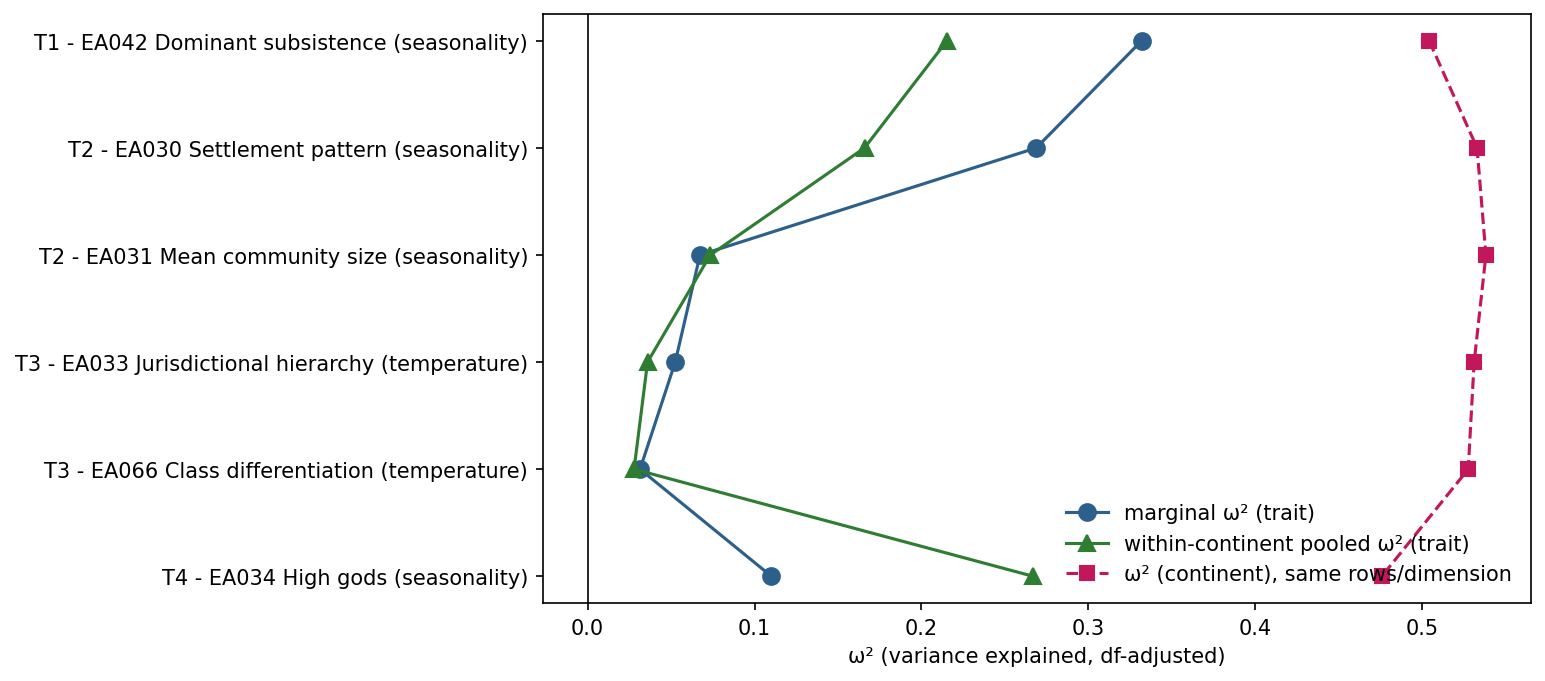

In [11]:
# Cell 11
print("drawing tier x marginal/within-continent/continent-comparator omega2 figure...")
order = attenuation_df.sort_values('tier', kind='stable').reset_index(drop=True)
cont_vals = [table3_df.loc[table3_df['trait'] == t, 'headline_dim_omega2'].iloc[0] for t in order['trait']]

fig, ax = plt.subplots(figsize=(8.5, 0.6 * len(order) + 1.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y = np.arange(len(order))[::-1]  # tier 1 at top
ax.plot(order['marginal_omega2'], y, 'o-', color='#2c5f8a', label='marginal ω² (trait)', markersize=8, zorder=3)
ax.plot(order['within_continent_omega2'], y, '^-', color='#2e7d32', label='within-continent pooled ω² (trait)', markersize=8, zorder=3)
ax.plot(cont_vals, y, 's--', color='#c2185b', label='ω² (continent), same rows/dimension', markersize=7, zorder=3)

labels = [f"T{t} - {tr} ({d})" for t, tr, d in zip(order['tier'], order['trait'], order['headline_dim'])]
ax.set_yticks(y)
ax.set_yticklabels(labels, color='black')
ax.set_xlabel('ω² (variance explained, df-adjusted)', color='black')
ax.axvline(0, color='black', linewidth=0.8, zorder=1)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_color('black')
ax.legend(frameon=False, labelcolor='black', loc='lower right')

outpath = OUT / 'wo3_tier_attenuation.png'
fig.savefig(outpath, facecolor='white', dpi=150, bbox_inches='tight')
plt.close(fig)
from IPython.display import Image as IPImage
display(IPImage(str(outpath)))


**Reading (Figure):** The chart makes Table 4's crossover legible at a glance: the marginal
(blue) and within-continent (green) markers swap relative order exactly once, at Tier 4 —
everywhere else marginal sits right of within-continent (attenuation, converging to near-overlap
at T2-EA031); at EA034 within-continent moves right of marginal instead. Continent's own baseline
(pink) stays well right of both trait series at every tier, visually confirming Table 3: continent
explains far more of temperature/seasonality than any trait, controlled or not, comes close to.

## Hazards

- ω² is a within-sample descriptive quantity; it is not an out-of-sample or causal estimate.
- Pooled within-continent estimates lose power where strata are thin; retained-stratum counts are
  reported per trait for that reason (Table 2).
- Continent is a coarse proxy for culture history and under-captures it, so the within-continent
  series is an upper bound on what survives real culture-history control.
- Traits within a tier are not independent — EA030 and EA031 especially.
- Basin-join loss (1,133 of 1,291 D-PLACE EA societies) is non-random with respect to environment
  and carries through unchanged.
- The percentile transformation is monotone but not linear; ω² is computed on ranks, so it
  describes rank variance, not variance in physical units.
- Within-continent pools are not a matched set across traits: Tier 3 (EA033/EA066) retains {Africa, Asia, Europe, North America} while Tiers 1/2/4 retain {Africa, Asia, North America, South America} — a non-overlapping continent swap, not just a smaller stratum count. Tier-to-tier comparisons involving EA033/EA066 carry this extra caveat on top of the general stratum-thinness one.

## Decision log

- **Negative ω² left unclipped.** ω² is an unbiased-but-noisy estimator and can compute below 0
  for a very weak effect; clipping to 0 would itself be an edit to the numbers the WO says to
  report, not test. A negative value is read as "indistinguishable from no effect," not zeroed
  out.
- **Max-dimension tie-break.** `max_dim`/`max_dim_eta2` use Python's `max()` over `VAR_KEYS` in
  declared order (aridity, temperature, seasonality, ruggedness, landform); an exact tie resolves
  to whichever comes first in that order. Not expected to bind — flagged in case it does.
- **Within-continent stratum floor computed once per trait, reused across all five dimensions**
  (`continent_strata()`), since the floor test (category count within continent) doesn't depend on
  the environmental variable at all — a computational simplification, not a change to the floor
  rule in WO3 Sec 4.
- **Table 3's row set is `trait_col.notna()`, not the trait's kept-category set** — WO3 Sec 3 says
  "rows where that trait is coded," read literally rather than as a synonym for Table 1/2's
  floor-restricted set. Continent categories within that row set are floored at the same n=20 used
  for trait categories (unstated in the WO, added here for the same small-category-instability
  reason the trait floor exists) — continents below it are dropped and reported (Table 3 columns).
- **`ari_log` re-derived locally** (Cell 4) rather than imported from `distance_core` or WO2,
  matching each notebook's standalone-execution rule.